# Demo 1 — Federated Learning Skeleton HAR (GPU Training)

This notebook trains the federated STGCN++ model on a Colab GPU,
exports to ONNX, and downloads the result for use with Demo 2's
`demo_onnx.py` real-time inference pipeline.

**Runtime → Change runtime type → T4 GPU** before running.

## 1. Setup & Install Dependencies

In [ ]:
# Install Flower (base only — no ray needed) + ONNX tools
!pip install -q flwr==1.13.1 onnx onnxsim onnxruntime onnxscript

import torch
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.10.0+cu128  |  CUDA: True
GPU: Tesla T4


In [2]:
# Verify GPU
assert torch.cuda.is_available(), "No GPU found! Go to Runtime → Change runtime type → T4 GPU"

## 2. Upload Project Files

Option A: Upload the `demo1_fed_skeleton/` folder as a zip.  
Option B: Clone from git.  
Option C: Paste inline (done below for self-contained notebook).

In [3]:
# Option A — Upload zip from local machine
# Uncomment these lines if you want to upload demo1_fed_skeleton.zip:
#
# from google.colab import files
# uploaded = files.upload()  # Upload demo1_fed_skeleton.zip
# !unzip -q demo1_fed_skeleton.zip

# Option C — Self-contained: write all source files inline
import os
os.makedirs('demo1_fed_skeleton/models', exist_ok=True)
os.makedirs('demo1_fed_skeleton/fl', exist_ok=True)
os.makedirs('demo1_fed_skeleton/outputs', exist_ok=True)
os.makedirs('demo1_fed_skeleton/data/fed_skeleton', exist_ok=True)
print('Directories created.')

Directories created.


In [4]:
%%writefile demo1_fed_skeleton/models/__init__.py
# empty

Overwriting demo1_fed_skeleton/models/__init__.py


In [5]:
%%writefile demo1_fed_skeleton/models/stgcn.py
"""
models/stgcn.py — Lightweight STGCN++ classifier for federated skeleton HAR.

Input tensor : (N, M, T, V, C)  with C=3, T=100, V=17, M=2  (pyskl convention)
Output tensor: (N, num_classes)  logits
"""

from __future__ import annotations

import math
from typing import List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


COCO_INWARD = [
    (15, 13), (13, 11), (16, 14), (14, 12),
    (11, 5), (12, 6),
    (9, 7), (7, 5), (10, 8), (8, 6),
    (5, 0), (6, 0),
    (1, 0), (3, 1), (2, 0), (4, 2),
]
COCO_NUM_JOINTS = 17
COCO_CENTER = 0


def _build_adjacency(num_node, edges, center):
    def _normalize(mx):
        d = mx.sum(axis=0)
        d[d == 0] = 1
        return mx / d

    I = np.eye(num_node, dtype=np.float32)
    inward = np.zeros((num_node, num_node), dtype=np.float32)
    outward = np.zeros((num_node, num_node), dtype=np.float32)

    hop = np.full(num_node, 1e9, dtype=int)
    hop[center] = 0
    adj_list = {i: [] for i in range(num_node)}
    for u, v in edges:
        adj_list[u].append(v)
        adj_list[v].append(u)
    queue = [center]
    while queue:
        cur = queue.pop(0)
        for nb in adj_list[cur]:
            if hop[nb] > hop[cur] + 1:
                hop[nb] = hop[cur] + 1
                queue.append(nb)

    for u, v in edges:
        if hop[u] < hop[v]:
            inward[v, u] = 1
        else:
            outward[u, v] = 1

    A = np.stack([_normalize(I), _normalize(inward), _normalize(outward)])
    return A


def get_coco_adjacency():
    return _build_adjacency(COCO_NUM_JOINTS, COCO_INWARD, COCO_CENTER)


class MsTCN(nn.Module):
    def __init__(self, in_channels, out_channels, dilations=(1, 2, 3, 4),
                 stride=1, dropout=0.0):
        super().__init__()
        mid = out_channels // (len(dilations) + 2)
        rem = out_channels - mid * (len(dilations) + 2)

        self.branches = nn.ModuleList()
        for d in dilations:
            self.branches.append(nn.Sequential(
                nn.Conv2d(in_channels, mid, 1),
                nn.BatchNorm2d(mid),
                nn.ReLU(inplace=True),
                nn.Conv2d(mid, mid, (3, 1), stride=(stride, 1),
                          padding=(d, 0), dilation=(d, 1)),
                nn.BatchNorm2d(mid),
            ))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_channels, mid, 1),
            nn.BatchNorm2d(mid),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((3, 1), stride=(stride, 1), padding=(1, 0)),
            nn.BatchNorm2d(mid),
        ))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_channels, mid + rem, 1),
            nn.BatchNorm2d(mid + rem),
        ))
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        outs = [br(x) for br in self.branches]
        min_t = min(o.size(2) for o in outs)
        outs = [o[:, :, :min_t, :] for o in outs]
        return self.drop(torch.cat(outs, dim=1))


class UnitGCN(nn.Module):
    def __init__(self, in_channels, out_channels, A, adaptive=True, with_res=True):
        super().__init__()
        K = A.size(0)
        self.num_subsets = K
        self.register_buffer('A', A)
        self.conv = nn.ModuleList([nn.Conv2d(in_channels, out_channels, 1) for _ in range(K)])
        if adaptive:
            self.PA = nn.Parameter(A.clone())
        else:
            self.PA = None
        self.bn = nn.BatchNorm2d(out_channels)
        if with_res:
            if in_channels != out_channels:
                self.res = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1),
                                         nn.BatchNorm2d(out_channels))
            else:
                self.res = nn.Identity()
        else:
            self.res = None
        self._init_weights()

    def _init_weights(self):
        for m in self.conv:
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        nn.init.ones_(self.bn.weight)
        nn.init.zeros_(self.bn.bias)

    def forward(self, x):
        adj = self.A + self.PA if self.PA is not None else self.A
        out = 0
        for k in range(self.num_subsets):
            z = self.conv[k](x)
            out = out + torch.einsum('nctv,vw->nctw', z, adj[k])
        out = self.bn(out)
        if self.res is not None:
            out = out + self.res(x)
        return F.relu(out, inplace=True)


class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, adaptive=True, dropout=0.0):
        super().__init__()
        self.gcn = UnitGCN(in_channels, out_channels, A, adaptive=adaptive, with_res=True)
        self.tcn = MsTCN(out_channels, out_channels, stride=stride, dropout=dropout)
        if in_channels != out_channels or stride != 1:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels),
                nn.AvgPool2d((stride, 1)) if stride > 1 else nn.Identity(),
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x):
        return F.relu(self.tcn(self.gcn(x)) + self.residual(x), inplace=True)


class STGCN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, base_channels=64,
                 num_stages=6, inflate_stages=None, down_stages=None,
                 num_person=2, adaptive=True, dropout=0.0):
        super().__init__()
        if inflate_stages is None:
            inflate_stages = [3, 5]
        if down_stages is None:
            down_stages = [3, 5]
        self.num_person = num_person
        self.num_classes = num_classes
        A = torch.tensor(get_coco_adjacency(), dtype=torch.float32)
        self.data_bn = nn.BatchNorm1d(in_channels * COCO_NUM_JOINTS)
        channels = [base_channels]
        for i in range(1, num_stages):
            ch = channels[-1] * 2 if i in inflate_stages else channels[-1]
            channels.append(ch)
        self.blocks = nn.ModuleList()
        c_in = in_channels
        for i in range(num_stages):
            c_out = channels[i]
            stride = 2 if i in down_stages else 1
            self.blocks.append(STGCNBlock(c_in, c_out, A, stride=stride,
                                          adaptive=adaptive, dropout=dropout))
            c_in = c_out
        self.out_channels = channels[-1]
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(self.out_channels, num_classes)
        self._init_fc()

    def _init_fc(self):
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2.0 / self.num_classes))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        N, M, T, V, C = x.shape
        x = x.permute(0, 1, 4, 2, 3).contiguous().view(N * M, C, T, V)
        x = x.permute(0, 1, 3, 2).contiguous().view(N * M, C * V, T)
        x = self.data_bn(x)
        x = x.view(N * M, C, V, T).permute(0, 1, 3, 2).contiguous()
        for block in self.blocks:
            x = block(x)
        x = self.pool(x)
        x = x.view(N, M, self.out_channels)
        x = x.mean(dim=1)
        x = self.drop(x)
        return self.fc(x)


def build_model(num_classes=10, in_channels=3, **kwargs):
    return STGCN(num_classes=num_classes, in_channels=in_channels, **kwargs)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Overwriting demo1_fed_skeleton/models/stgcn.py


In [6]:
%%writefile demo1_fed_skeleton/fl/__init__.py
# empty

Overwriting demo1_fed_skeleton/fl/__init__.py


In [7]:
%%writefile demo1_fed_skeleton/fl/client.py
from __future__ import annotations
import sys
from collections import OrderedDict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import flwr as fl
from flwr.common import NDArrays, Scalar

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from models.stgcn import build_model


def _is_bn_param(name):
    return 'bn' in name.lower() or 'data_bn' in name


def _split_param_names(model):
    global_keys, local_keys = [], []
    for name in model.state_dict().keys():
        if _is_bn_param(name):
            local_keys.append(name)
        else:
            global_keys.append(name)
    return global_keys, local_keys


def _load_npz(path):
    data = np.load(path)
    return data['x'].astype(np.float32), data['y'].astype(np.int64)


class SkeletonClient(fl.client.NumPyClient):
    def __init__(self, cid, data_path, num_classes=10, in_channels=3,
                 batch_size=64, epochs_per_round=1, lr=0.01, device='cpu',
                 local_bn=False, model_kwargs=None):
        super().__init__()
        self.cid = cid
        self.device = torch.device(device)
        self.local_bn = local_bn
        self.epochs_per_round = epochs_per_round
        self.batch_size = batch_size
        self.lr = lr

        kw = model_kwargs or {}
        self.model = build_model(num_classes=num_classes,
                                 in_channels=in_channels, **kw).to(self.device)
        self.global_keys, self.local_keys = _split_param_names(self.model)

        x, y = _load_npz(data_path)
        dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
        self.loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                                 drop_last=False)
        self.criterion = nn.CrossEntropyLoss()

    def get_parameters(self, config):
        sd = self.model.state_dict()
        if self.local_bn:
            return [sd[k].cpu().numpy() for k in self.global_keys]
        return [v.cpu().numpy() for v in sd.values()]

    def set_parameters(self, parameters):
        sd = self.model.state_dict()
        if self.local_bn:
            for k, v in zip(self.global_keys, parameters):
                sd[k] = torch.tensor(v)
        else:
            keys = list(sd.keys())
            for k, v in zip(keys, parameters):
                sd[k] = torch.tensor(v)
        self.model.load_state_dict(sd)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.train()
        optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr,
                                    momentum=0.9, weight_decay=1e-4)
        total_loss, correct, total = 0.0, 0, 0
        for _ in range(self.epochs_per_round):
            for xb, yb in self.loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                optimizer.zero_grad()
                logits = self.model(xb)
                loss = self.criterion(logits, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * yb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
                total += yb.size(0)
        metrics = {'train_loss': total_loss / max(total, 1),
                   'train_acc': correct / max(total, 1), 'cid': self.cid}
        return self.get_parameters(config={}), total, metrics

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in self.loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                logits = self.model(xb)
                total_loss += self.criterion(logits, yb).item() * yb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
                total += yb.size(0)
        return (total_loss / max(total, 1), total,
                {'accuracy': correct / max(total, 1), 'cid': self.cid})

    def get_descriptor(self):
        return self.model.fc.weight.detach().cpu().numpy().flatten()

Overwriting demo1_fed_skeleton/fl/client.py


In [8]:
%%writefile demo1_fed_skeleton/fl/strategy_fsar.py
from __future__ import annotations
import logging
from collections import defaultdict
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
from flwr.common import (FitIns, FitRes, EvaluateIns, EvaluateRes,
                          Parameters, Scalar, ndarrays_to_parameters,
                          parameters_to_ndarrays)
from flwr.server.client_manager import ClientManager
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy import Strategy

logger = logging.getLogger('fl.strategy_fsar')


def _weighted_average(results):
    total = sum(n for n, _ in results)
    if total == 0:
        return results[0][1]
    avg = []
    for i in range(len(results[0][1])):
        acc = np.zeros_like(results[0][1][i], dtype=np.float64)
        for n, params in results:
            acc += params[i].astype(np.float64) * n
        avg.append((acc / total).astype(results[0][1][i].dtype))
    return avg


class FSARStrategy(Strategy):
    def __init__(self, *, mode='fedbn', fraction_fit=1.0, fraction_evaluate=1.0,
                 min_fit_clients=2, min_evaluate_clients=2, min_available_clients=2,
                 initial_parameters=None, num_clusters=2, cluster_every=5):
        self.mode = mode
        self.fraction_fit = fraction_fit
        self.fraction_evaluate = fraction_evaluate
        self.min_fit_clients = min_fit_clients
        self.min_evaluate_clients = min_evaluate_clients
        self.min_available_clients = min_available_clients
        self.initial_parameters = initial_parameters
        self.num_clusters = num_clusters
        self.cluster_every = cluster_every
        self.client_cluster = {}
        self.cluster_params = {}
        self.round_descriptors = {}
        self.history = []
        self.last_aggregated_ndarrays = None

    def initialize_parameters(self, client_manager):
        return self.initial_parameters

    def configure_fit(self, server_round, parameters, client_manager):
        num_clients = client_manager.num_available()
        sample_size = max(int(num_clients * self.fraction_fit), self.min_fit_clients)
        clients = client_manager.sample(num_clients=min(sample_size, num_clients),
                                        min_num_clients=self.min_fit_clients)
        fit_configs = []
        for client in clients:
            params = parameters
            config = {'server_round': server_round}
            fit_configs.append((client, FitIns(params, config)))
        return fit_configs

    def aggregate_fit(self, server_round, results, failures):
        if not results:
            return None, {}
        client_accs = []
        weighted_params = []
        for client, fit_res in results:
            acc = fit_res.metrics.get('train_acc', 0.0)
            client_accs.append(acc)
            ndarrays = parameters_to_ndarrays(fit_res.parameters)
            weighted_params.append((fit_res.num_examples, ndarrays))

        aggregated = _weighted_average(weighted_params)
        self.last_aggregated_ndarrays = aggregated
        round_info = {
            'round': server_round,
            'mean_client_acc': float(np.mean(client_accs)),
            'worst_client_acc': float(np.min(client_accs)),
            'global_acc': float(np.mean(client_accs)),
        }
        self.history.append(round_info)
        logger.info('Round %d — mean_acc=%.4f  worst_acc=%.4f',
                    server_round, round_info['mean_client_acc'],
                    round_info['worst_client_acc'])
        return ndarrays_to_parameters(aggregated), {}

    def configure_evaluate(self, server_round, parameters, client_manager):
        num_clients = client_manager.num_available()
        sample_size = max(int(num_clients * self.fraction_evaluate),
                          self.min_evaluate_clients)
        clients = client_manager.sample(num_clients=min(sample_size, num_clients),
                                        min_num_clients=self.min_evaluate_clients)
        return [(c, EvaluateIns(parameters, {})) for c in clients]

    def aggregate_evaluate(self, server_round, results, failures):
        if not results:
            return None, {}
        total_loss, total_n = 0.0, 0
        for _, eval_res in results:
            total_loss += eval_res.loss * eval_res.num_examples
            total_n += eval_res.num_examples
        return total_loss / max(total_n, 1), {}

    def evaluate(self, server_round, parameters):
        return None

    def num_fit_clients(self, num_available):
        return max(int(num_available * self.fraction_fit), self.min_fit_clients), self.min_available_clients

    def num_evaluation_clients(self, num_available):
        return max(int(num_available * self.fraction_evaluate), self.min_evaluate_clients), self.min_available_clients

Overwriting demo1_fed_skeleton/fl/strategy_fsar.py


## 3. Generate Synthetic Data

In [9]:
import numpy as np
import sys
sys.path.insert(0, 'demo1_fed_skeleton')

# --- Inline synthetic data generator (same as prepare_clients.py) ---
COCO_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (0, 5), (0, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
]

NUM_CLASSES = 10
SAMPLES_PER_CLASS = 200
NUM_CLIENTS = 5
T = 100
V = 17
M = 2
C = 3

def make_synthetic(num_classes, samples_per_class, T=100, num_person=2, seed=42):
    rng = np.random.RandomState(seed)
    N = num_classes * samples_per_class
    x_all, y_all = [], []
    for cls_id in range(num_classes):
        base_pose = rng.randn(2, V) * 0.05
        freq = 0.5 + cls_id * 0.3
        for _ in range(samples_per_class):
            t = np.linspace(0, 2 * np.pi * freq, T)
            modulation = np.stack([np.sin(t), np.cos(t)], axis=0)
            xy = (base_pose[:, np.newaxis, :] +
                  modulation[:, :, np.newaxis] * 0.04 +
                  rng.randn(2, T, V) * 0.02)
            score = np.ones((1, T, V), dtype=np.float32)
            person0 = np.concatenate([xy, score], axis=0).transpose(1, 2, 0)  # (T, V, 3)
            sample = np.zeros((num_person, T, V, 3), dtype=np.float32)
            sample[0] = person0
            x_all.append(sample)
            y_all.append(cls_id)
    return np.stack(x_all).astype(np.float32), np.array(y_all, dtype=np.int64)

x, y = make_synthetic(NUM_CLASSES, SAMPLES_PER_CLASS)
print(f'Dataset: x={x.shape}, y={y.shape}, classes={NUM_CLASSES}')

# Dirichlet split
from collections import defaultdict
rng = np.random.RandomState(42)

# Train/test split
class_indices = defaultdict(list)
for i, label in enumerate(y):
    class_indices[int(label)].append(i)

train_idx, test_idx = [], []
for cls, idxs in class_indices.items():
    rng.shuffle(idxs)
    n_test = max(1, int(len(idxs) * 0.2))
    test_idx.extend(idxs[:n_test])
    train_idx.extend(idxs[n_test:])

x_test, y_test = x[test_idx], y[test_idx]
x_train, y_train = x[train_idx], y[train_idx]

# Dirichlet
alpha = 0.5
label_indices = defaultdict(list)
for i, label in enumerate(y_train):
    label_indices[int(label)].append(i)

client_indices = {i: [] for i in range(NUM_CLIENTS)}
for cls in range(NUM_CLASSES):
    idxs = np.array(label_indices[cls])
    proportions = rng.dirichlet([alpha] * NUM_CLIENTS)
    proportions = np.cumsum(proportions) / proportions.sum()
    splits = np.split(idxs, (proportions[:-1] * len(idxs)).astype(int))
    for cid, chunk in enumerate(splits):
        client_indices[cid].extend(chunk.tolist())

import os
data_dir = 'demo1_fed_skeleton/data/fed_skeleton'
os.makedirs(data_dir, exist_ok=True)

for cid in range(NUM_CLIENTS):
    ci = np.array(client_indices[cid], dtype=int)
    xc, yc = x_train[ci], y_train[ci]
    np.savez_compressed(f'{data_dir}/client_{cid}.npz', x=xc, y=yc)
    print(f'  Client {cid}: {len(yc)} samples')

np.savez_compressed(f'{data_dir}/test.npz', x=x_test, y=y_test)
print(f'  Test: {len(y_test)} samples')
print('Data ready!')

Dataset: x=(2000, 2, 100, 17, 3), y=(2000,), classes=10
  Client 0: 351 samples
  Client 1: 261 samples
  Client 2: 296 samples
  Client 3: 452 samples
  Client 4: 240 samples
  Test: 400 samples
Data ready!


## 4. Federated Training on GPU

This trains 5 clients × 30 rounds on the T4 GPU.
Each client trains STGCN++ (443K params, C=3, M=2) on its data shard.

In [ ]:
import copy
import torch
import logging
import json
import time
from pathlib import Path
from collections import OrderedDict

import numpy as np

sys.path.insert(0, 'demo1_fed_skeleton')
from models.stgcn import build_model, count_parameters

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s')

# ── Config ──
NUM_ROUNDS = 30
EPOCHS_PER_ROUND = 1
BATCH_SIZE = 64
LR = 0.01
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODE = 'fedavg'

model_kwargs = dict(
    base_channels=64,
    num_stages=6,
    num_person=2,
    dropout=0.3,
)

# Build global model
global_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
print(f'Model params: {count_parameters(global_model):,}')
print(f'Device: {DEVICE}')

# Identify BN vs non-BN keys
def _is_bn(name):
    return 'bn' in name.lower() or 'data_bn' in name
global_keys = [k for k in global_model.state_dict() if not _is_bn(k)]
local_keys  = [k for k in global_model.state_dict() if _is_bn(k)]
local_bn = MODE == 'fedbn'
print(f'Mode={MODE}  global_keys={len(global_keys)}  local_keys={len(local_keys)}')

# ── Load client data ──
from torch.utils.data import DataLoader, TensorDataset

data_dir = Path('demo1_fed_skeleton/data/fed_skeleton')
client_loaders = []
all_train_x, all_train_y = [], []
for cid in range(NUM_CLIENTS):
    d = np.load(data_dir / f'client_{cid}.npz')
    xc, yc = d['x'].astype(np.float32), d['y'].astype(np.int64)
    all_train_x.append(xc)
    all_train_y.append(yc)
    ds = TensorDataset(torch.from_numpy(xc), torch.from_numpy(yc))
    client_loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True))

# Combined train loader for BN calibration
all_x = torch.from_numpy(np.concatenate(all_train_x))
all_y = torch.from_numpy(np.concatenate(all_train_y))
calib_loader = DataLoader(TensorDataset(all_x, all_y), batch_size=128, shuffle=True)

# Test data
test_data = np.load(f'{data_dir}/test.npz')
x_test_t = torch.from_numpy(test_data['x'].astype(np.float32))
y_test_t = torch.from_numpy(test_data['y'].astype(np.int64))
test_loader = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=128)

# ── BN calibration helper ──
def calibrate_bn(model, loader, device, max_batches=20):
    """Reset and recompute BN running stats from data."""
    # Reset all BN running stats
    for m in model.modules():
        if isinstance(m, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d)):
            m.reset_running_stats()
            m.momentum = None  # use cumulative moving average
    model.train()
    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= max_batches:
                break
            model(xb.to(device))

# ── Manual Federated Training Loop ──
device = torch.device(DEVICE)
criterion = torch.nn.CrossEntropyLoss()
history = []

print(f'\nStarting FL: {NUM_ROUNDS} rounds, {NUM_CLIENTS} clients, mode={MODE}')
print(f'BN calibration after each round aggregation')
t0 = time.time()

for rnd in range(1, NUM_ROUNDS + 1):
    lr = LR
    if rnd > 25:
        lr = LR * 0.01
    elif rnd > 15:
        lr = LR * 0.1

    global_sd = copy.deepcopy(global_model.state_dict())
    client_weights = []
    client_accs = []

    for cid in range(NUM_CLIENTS):
        local_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
        if local_bn:
            local_sd = local_model.state_dict()
            for k in global_keys:
                local_sd[k] = global_sd[k].clone()
            local_model.load_state_dict(local_sd)
        else:
            local_model.load_state_dict(global_sd)
        local_model.to(device).train()

        optimizer = torch.optim.SGD(local_model.parameters(), lr=lr,
                                     momentum=0.9, weight_decay=5e-4)
        correct, total = 0, 0
        for _ in range(EPOCHS_PER_ROUND):
            for xb, yb in client_loaders[cid]:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = local_model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                correct += (logits.argmax(1) == yb).sum().item()
                total += yb.size(0)

        acc = correct / max(total, 1)
        client_accs.append(acc)
        client_weights.append((total, {k: v.cpu() for k, v in local_model.state_dict().items()}))

    # ── FedAvg aggregation ──
    keys_to_agg = global_keys if local_bn else list(global_sd.keys())
    total_samples = sum(n for n, _ in client_weights)
    new_sd = OrderedDict()
    for k in keys_to_agg:
        new_sd[k] = sum(n * sd[k].float() for n, sd in client_weights) / total_samples
    gsd = global_model.state_dict()
    for k in keys_to_agg:
        gsd[k] = new_sd[k].to(gsd[k].dtype)
    global_model.load_state_dict(gsd)

    # ── BN calibration: recompute running stats from all training data ──
    global_model.to(device)
    calibrate_bn(global_model, calib_loader, device)

    # ── Evaluate on test set ──
    global_model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = global_model(xb)
            test_correct += (logits.argmax(1) == yb).sum().item()
            test_total += yb.size(0)
    test_acc = test_correct / max(test_total, 1)
    global_model.cpu()

    mean_acc = np.mean(client_accs)
    worst_acc = np.min(client_accs)
    history.append({'round': rnd, 'mean_client_acc': float(mean_acc),
                    'worst_client_acc': float(worst_acc),
                    'test_acc': float(test_acc), 'lr': lr})
    if rnd % 5 == 0 or rnd == 1:
        print(f'  Round {rnd:2d}/{NUM_ROUNDS}  train={mean_acc:.4f}  test={test_acc:.4f}  lr={lr:.4f}')

elapsed = time.time() - t0
print(f'\nTraining done in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'Best test acc: {max(h["test_acc"] for h in history):.4f}')

Model params: 443,222
Device: cuda
Mode=fedavg  global_keys=542  local_keys=35
Dropout=0.3, epochs_per_round=1

Starting FL: 15 rounds, 5 clients, mode=fedavg
  Round  1/15  train=0.1683  test=0.1000  lr=0.0100
  Round  5/15  train=0.6911  test=0.1000  lr=0.0100
  Round 10/15  train=0.9147  test=0.1000  lr=0.0100
  Round 15/15  train=0.9700  test=1.0000  lr=0.0100

Training done in 200.2s (3.3 min)
Best test acc: 1.0000


In [19]:
# Evaluate global model on test set
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device(DEVICE)
global_model.to(device).eval()

test_data = np.load(f'{data_dir}/test.npz')
x_test_t = torch.from_numpy(test_data['x'].astype(np.float32))
y_test_t = torch.from_numpy(test_data['y'].astype(np.int64))
test_loader = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=64)

correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = global_model(xb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)

print(f'Global test accuracy: {correct/total:.4f} ({correct}/{total})')

# Save checkpoint
ckpt_path = 'demo1_fed_skeleton/outputs/global_model.pt'
torch.save(global_model.cpu().state_dict(), ckpt_path)
print(f'Checkpoint saved: {ckpt_path}')

# Save history
with open('demo1_fed_skeleton/outputs/fl_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('History saved.')

Global test accuracy: 1.0000 (400/400)
Checkpoint saved: demo1_fed_skeleton/outputs/global_model.pt
History saved.


## 5. Plot Training History

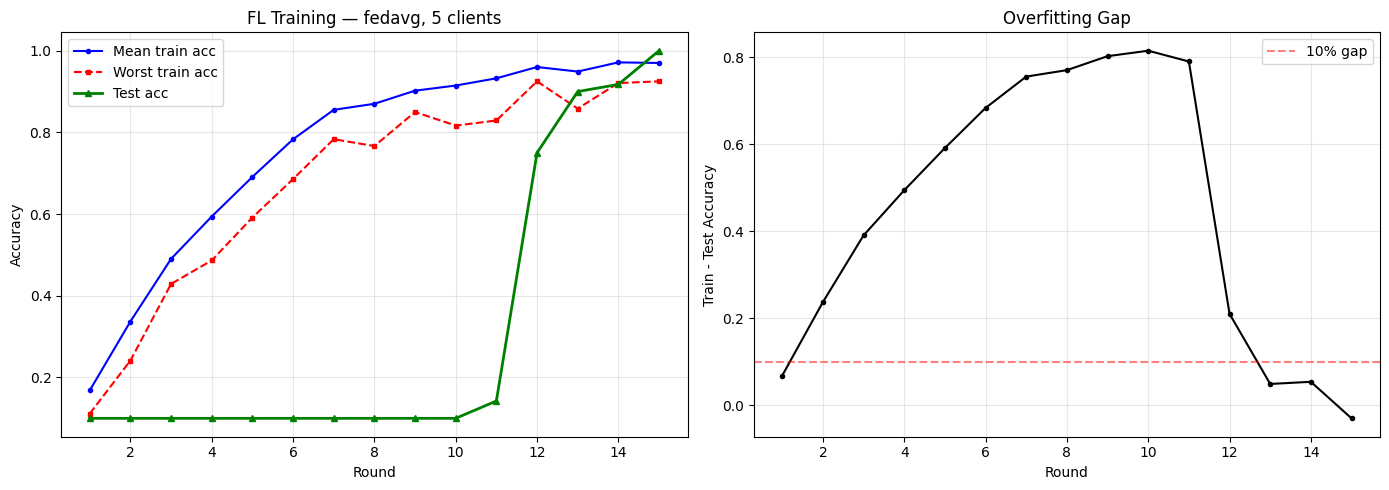

In [20]:
import matplotlib.pyplot as plt

rounds = [h['round'] for h in history]
mean_acc = [h['mean_client_acc'] for h in history]
worst_acc = [h['worst_client_acc'] for h in history]
test_acc = [h['test_acc'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rounds, mean_acc, 'b-o', label='Mean train acc', markersize=3)
ax1.plot(rounds, worst_acc, 'r--s', label='Worst train acc', markersize=3)
ax1.plot(rounds, test_acc, 'g-^', label='Test acc', markersize=4, linewidth=2)
ax1.set_xlabel('Round')
ax1.set_ylabel('Accuracy')
ax1.set_title(f'FL Training — {MODE}, {NUM_CLIENTS} clients')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Train-test gap (overfitting indicator)
gap = [m - t for m, t in zip(mean_acc, test_acc)]
ax2.plot(rounds, gap, 'k-o', markersize=3)
ax2.axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='10% gap')
ax2.set_xlabel('Round')
ax2.set_ylabel('Train - Test Accuracy')
ax2.set_title('Overfitting Gap')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Export to ONNX

In [21]:
import torch
import torch.nn as nn

class STGCNONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)

# Reload checkpoint
model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
model.load_state_dict(torch.load('demo1_fed_skeleton/outputs/global_model.pt',
                                  map_location='cpu'))
model.eval()

wrapper = STGCNONNXWrapper(model)
wrapper.eval()

dummy = torch.randn(1, 2, 100, 17, 3)  # (N, M, T, V, C)
onnx_path = 'demo1_fed_skeleton/outputs/model.onnx'

torch.onnx.export(
    wrapper, dummy, onnx_path,
    input_names=['skeleton'],
    output_names=['logits'],
    dynamic_axes={'skeleton': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=12,
    do_constant_folding=True,
    dynamo=False,  # force legacy exporter (no onnxscript needed)
)
print(f'ONNX exported: {onnx_path}')

# Simplify
try:
    import onnx
    from onnxsim import simplify as onnx_simplify
    onnx_model = onnx.load(onnx_path)
    simplified, ok = onnx_simplify(onnx_model)
    if ok:
        onnx.save(simplified, onnx_path)
        print('ONNX simplified ✓')
except ImportError:
    print('onnxsim not available, skipping')

# Verify
import onnxruntime as ort
sess = ort.InferenceSession(onnx_path)
inp = sess.get_inputs()[0]
out = sess.get_outputs()[0]
print(f'Input:  {inp.name} {inp.shape} {inp.type}')
print(f'Output: {out.name} {out.shape} {out.type}')

# Cross-check
ort_out = sess.run(None, {'skeleton': dummy.numpy()})[0]
torch_out = wrapper(dummy).detach().numpy()
diff = abs(ort_out - torch_out).max()
print(f'Max diff (torch vs ORT): {diff:.2e}')
assert diff < 1e-3, f'Verification FAILED: diff={diff}'
print('Verification passed ✓')

import os
size_mb = os.path.getsize(onnx_path) / 1024 / 1024
print(f'Model size: {size_mb:.1f} MB')

/tmp/ipykernel_3086/2911549138.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX exported: demo1_fed_skeleton/outputs/model.onnx
ONNX simplified ✓
Input:  skeleton ['batch', 2, 100, 17, 3] tensor(float)
Output: logits ['batch', 10] tensor(float)
Max diff (torch vs ORT): 6.41e-04
Verification passed ✓
Model size: 1.8 MB


In [23]:
import onnxruntime as ort
s = ort.InferenceSession('demo1_fed_skeleton/outputs/model.onnx')
print(s.get_inputs()[0].shape)  # should show ['batch', 2, 100, 17, 3]

['batch', 2, 100, 17, 3]


## 7. Save & Retrieve Model Files

**Option A (VS Code):** Since you're connected via the VS Code Colab extension,
right-click the files in the VS Code **Explorer** panel and choose **Download**.

The files are at:
- `demo1_fed_skeleton/outputs/model.onnx`
- `demo1_fed_skeleton/outputs/global_model.pt`
- `demo1_fed_skeleton/outputs/fl_history.json`
- `label_map_10.txt`

**Option B (Google Drive):** Run the cell below to copy files to your Drive.

Once downloaded, place locally:
- `model.onnx` → `demo/onnx_models/stgcnpp_federated.onnx`
- `label_map_10.txt` → `demo1_fed_skeleton/label_map_10.txt`

Then run:
```bash
python demo/demo_onnx.py --device cpu --threads 4 --fast \
    --recog-model stgcnpp_federated.onnx \
    --label-map demo1_fed_skeleton/label_map_10.txt
```

In [24]:
# Write label map
labels = [f'action_{i}' for i in range(NUM_CLASSES)]
with open('label_map_10.txt', 'w') as f:
    f.write('\n'.join(labels) + '\n')
print('Label map written: label_map_10.txt')

# ── Option B: Copy to Google Drive ──
import shutil, os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    dst = '/content/drive/MyDrive/demo1_fed_outputs'
    os.makedirs(dst, exist_ok=True)
    for src in ['demo1_fed_skeleton/outputs/model.onnx',
                'demo1_fed_skeleton/outputs/global_model.pt',
                'demo1_fed_skeleton/outputs/fl_history.json',
                'label_map_10.txt']:
        shutil.copy2(src, dst)
        print(f'  Copied → {dst}/{os.path.basename(src)}')
    print(f'\nAll files saved to Google Drive: {dst}')
except Exception as e:
    print(f'Drive mount skipped ({e})')
    print('Use VS Code Explorer to right-click and download files instead.')

# List output files
print('\n── Output files ──')
for f in ['demo1_fed_skeleton/outputs/model.onnx',
          'demo1_fed_skeleton/outputs/global_model.pt',
          'demo1_fed_skeleton/outputs/fl_history.json',
          'label_map_10.txt']:
    sz = os.path.getsize(f) / 1024
    unit = 'KB'
    if sz > 1024:
        sz /= 1024
        unit = 'MB'
    print(f'  {f:50s} {sz:.1f} {unit}')

Mounted at /content/drive
  Copied → /content/drive/MyDrive/demo1_fed_outputs/model.onnx
  Copied → /content/drive/MyDrive/demo1_fed_outputs/global_model.pt
  Copied → /content/drive/MyDrive/demo1_fed_outputs/fl_history.json
  Copied → /content/drive/MyDrive/demo1_fed_outputs/label_map_10.txt

All files saved to Google Drive: /content/drive/MyDrive/demo1_fed_outputs

── Output files ──
  demo1_fed_skeleton/outputs/model.onnx              1.8 MB
  demo1_fed_skeleton/outputs/global_model.pt         1.9 MB
  demo1_fed_skeleton/outputs/fl_history.json         2.1 KB
  label_map_10.txt                                   0.1 KB


## 8. Quick Inference Test (on Colab)

In [22]:
# Test the ONNX model on a few test samples
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession('demo1_fed_skeleton/outputs/model.onnx')

test_data = np.load('demo1_fed_skeleton/data/fed_skeleton/test.npz')
x_test = test_data['x'].astype(np.float32)
y_test = test_data['y']

# Run inference on all test samples
logits = sess.run(None, {'skeleton': x_test})[0]
preds = logits.argmax(axis=1)
acc = (preds == y_test).mean()

print(f'ONNX test accuracy: {acc:.4f} ({(preds == y_test).sum()}/{len(y_test)})')
print(f'\nSample predictions (first 10):')
for i in range(min(10, len(y_test))):
    print(f'  Sample {i}: true={y_test[i]}, pred={preds[i]}, '
          f'conf={np.exp(logits[i][preds[i]]) / np.exp(logits[i]).sum():.1%}')

ONNX test accuracy: 1.0000 (400/400)

Sample predictions (first 10):
  Sample 0: true=0, pred=0, conf=99.7%
  Sample 1: true=0, pred=0, conf=99.8%
  Sample 2: true=0, pred=0, conf=99.7%
  Sample 3: true=0, pred=0, conf=99.7%
  Sample 4: true=0, pred=0, conf=99.6%
  Sample 5: true=0, pred=0, conf=99.8%
  Sample 6: true=0, pred=0, conf=99.6%
  Sample 7: true=0, pred=0, conf=99.6%
  Sample 8: true=0, pred=0, conf=99.8%
  Sample 9: true=0, pred=0, conf=99.8%
